In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import numpy as np

# ===== Cấu hình =====
input_base_dir = "/kaggle/input/valid-data"       # folder gốc
output_base_dir = "valid-augment"  # folder lưu ảnh augment
os.makedirs(output_base_dir, exist_ok=True)

# Thiết lập augmentation (tỉ lệ an toàn cho MRI/CT)
datagen = ImageDataGenerator(
    rescale=1./255,            # chuẩn hóa pixel
    shear_range=0.05,          # biến dạng nhẹ
    zoom_range=0.1,            # zoom ±10%
    rotation_range=12,         # xoay ±12 độ
    width_shift_range=0.05,    # dịch ngang ±5%
    height_shift_range=0.05,   # dịch dọc ±5%
    horizontal_flip=True,      # lật ngang (chỉ khi không quan trọng trái-phải)
    brightness_range=[0.9, 1.1],  # điều chỉnh sáng nhẹ ±10%
    fill_mode='nearest'        # tránh viền đen
)

# Số lượng ảnh augment mỗi ảnh gốc
num_augmented = 3

# Lặp qua từng class folder
for class_folder in os.listdir(input_base_dir):
    input_class_dir = os.path.join(input_base_dir, class_folder)
    output_class_dir = os.path.join(output_base_dir, class_folder)
    os.makedirs(output_class_dir, exist_ok=True)

    for filename in os.listdir(input_class_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(input_class_dir, filename)
            img = load_img(img_path)
            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)

            prefix = os.path.splitext(filename)[0]
            i = 0
            for batch in datagen.flow(
                x,
                batch_size=1,
                save_to_dir=output_class_dir,
                save_prefix=prefix,
                save_format='jpg'
            ):
                i += 1
                if i >= num_augmented:
                    break

print("✅ Augmentation hoàn tất! Ảnh mới lưu trong:", output_base_dir)


Epoch 1/30 | Train Loss: 0.5350 | Train Acc: 0.7714 | Val Loss: 0.5301 | Val Acc: 0.7063
Epoch 2/30 | Train Loss: 0.2339 | Train Acc: 0.9375 | Val Loss: 0.3470 | Val Acc: 0.8375
Epoch 3/30 | Train Loss: 0.0969 | Train Acc: 0.9839 | Val Loss: 0.2430 | Val Acc: 0.9000
Epoch 4/30 | Train Loss: 0.0395 | Train Acc: 0.9946 | Val Loss: 0.3126 | Val Acc: 0.8875
Epoch 5/30 | Train Loss: 0.0301 | Train Acc: 0.9982 | Val Loss: 0.2314 | Val Acc: 0.9313
Epoch 6/30 | Train Loss: 0.0248 | Train Acc: 0.9964 | Val Loss: 0.2991 | Val Acc: 0.8938
Epoch 7/30 | Train Loss: 0.0170 | Train Acc: 0.9964 | Val Loss: 0.3165 | Val Acc: 0.8875
Epoch 8/30 | Train Loss: 0.0138 | Train Acc: 0.9982 | Val Loss: 0.3719 | Val Acc: 0.8625
Epoch 9/30 | Train Loss: 0.0159 | Train Acc: 0.9946 | Val Loss: 0.3623 | Val Acc: 0.8500
Epoch 10/30 | Train Loss: 0.0070 | Train Acc: 0.9982 | Val Loss: 0.3565 | Val Acc: 0.8688
Epoch 11/30 | Train Loss: 0.0055 | Train Acc: 1.0000 | Val Loss: 0.3430 | Val Acc: 0.8875
Epoch 12/30 | Train

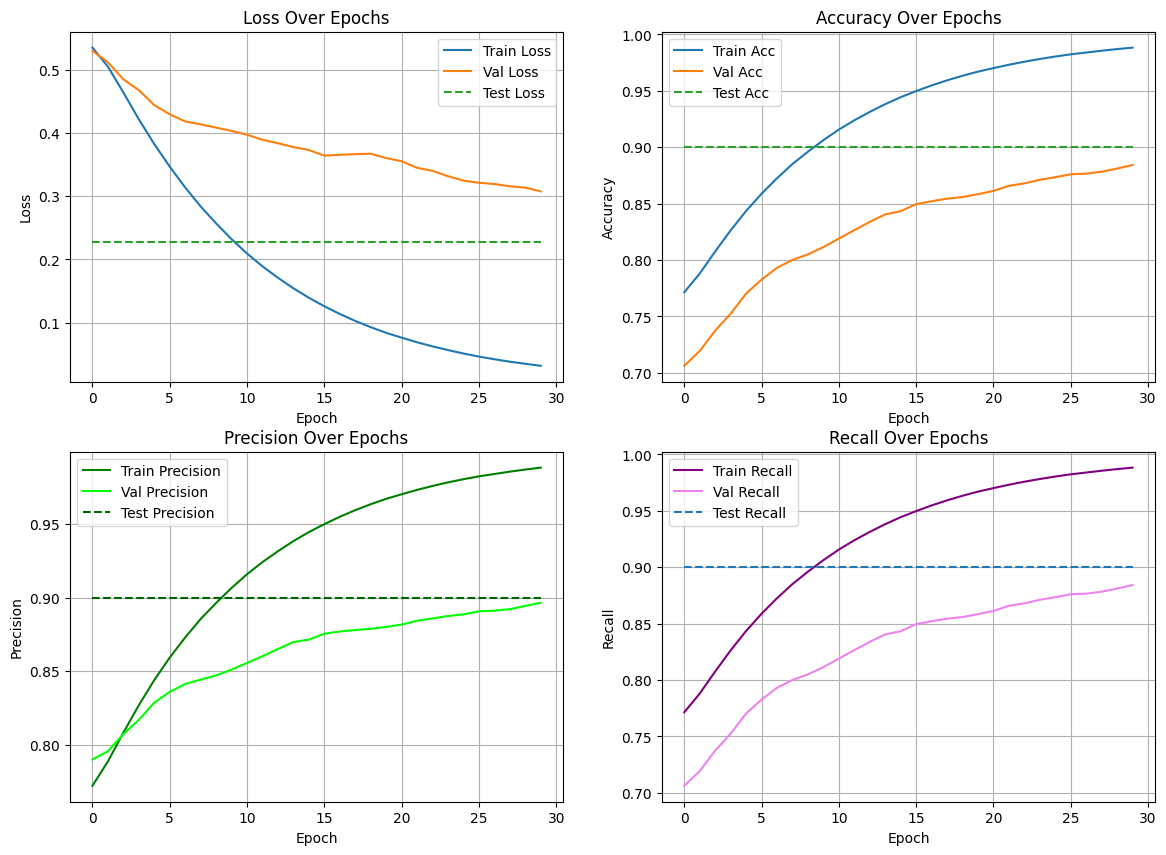

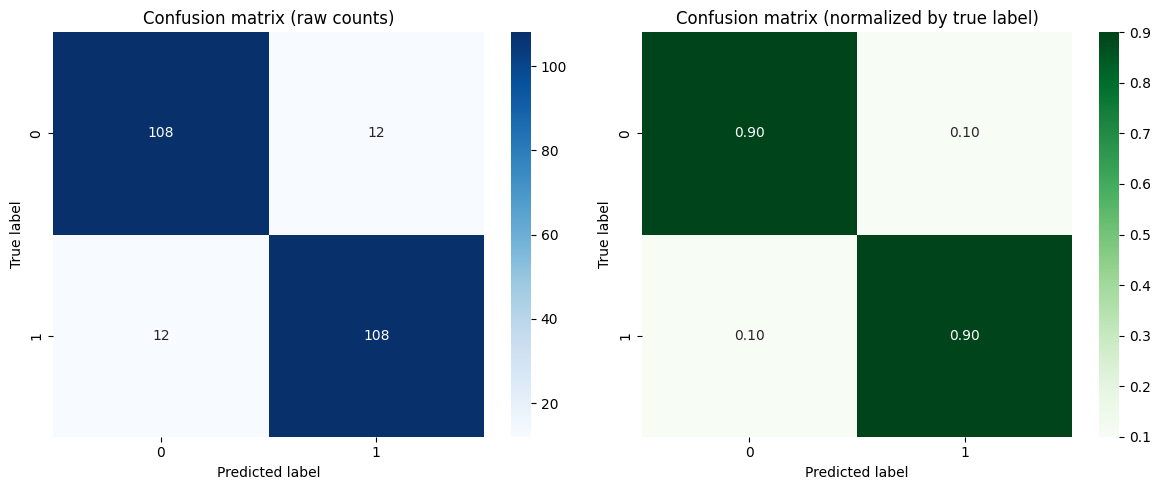

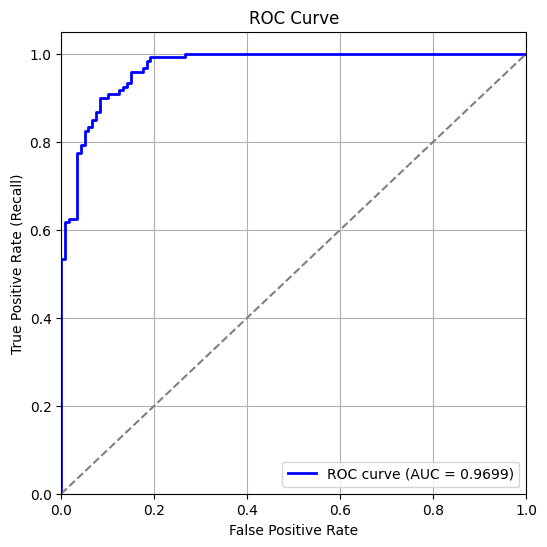

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V2_Weights
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score
import matplotlib.pyplot as plt

# Thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tiền xử lý
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Tăng kích thước ảnh
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Dữ liệu
train_set = datasets.ImageFolder("/kaggle/input/train-set/training_set/training_set", transform=train_transform)
train_aug = datasets.ImageFolder("/kaggle/input/train-augment/training_set_augmented/training_set_augmented", transform=train_transform)
train_data = ConcatDataset([train_set, train_aug])

val_set = datasets.ImageFolder("/kaggle/input/valid-data/validation_set/validation_set", transform=eval_transform)
val_aug = datasets.ImageFolder("/kaggle/input/valid-augment/validation_augmented/validation_augmented", transform=eval_transform)
val_data = ConcatDataset([val_set, val_aug])

test_set = datasets.ImageFolder("/kaggle/input/test-data/test_set/test_set", transform=eval_transform)
test_aug = datasets.ImageFolder("/kaggle/input/test-set-augmented/test_set_augmented/test_set_augmented", transform=eval_transform)
test_data = ConcatDataset([test_set, test_aug])

# DataLoader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

# Mô hình
model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

# Chỉ fine-tune block cuối
for name, param in model.features.named_parameters():
    param.requires_grad = False
    if "16" in name or "17" in name or "18" in name:
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.last_channel, 2)
)
model = model.to(device)

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# Hàm làm mượt và đóng băng
def smooth_curve(points, factor=0.9):
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

def freeze_after(values, freeze_epoch):
    return [values[i] if i < freeze_epoch else values[freeze_epoch] for i in range(len(values))]

# Huấn luyện
num_epochs = 30
best_val_loss = float('inf')
patience = 5
counter = 0
freeze_epoch = num_epochs

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_precisions, val_precisions = [], []
train_recalls, val_recalls = [], []
test_losses, test_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    all_train_preds, all_train_labels = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(correct / total)
    train_precisions.append(precision_score(all_train_labels, all_train_preds, average='macro', zero_division=0))
    train_recalls.append(recall_score(all_train_labels, all_train_preds, average='macro', zero_division=0))

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    all_val_preds, all_val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_val_preds.extend(preds.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(correct / total)
    val_precisions.append(precision_score(all_val_labels, all_val_preds, average='macro', zero_division=0))
    val_recalls.append(recall_score(all_val_labels, all_val_preds, average='macro', zero_division=0))
    scheduler.step(val_losses[-1])

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accuracies[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accuracies[-1]:.4f}")

# Đánh giá test
model.eval()
test_loss, correct, total = 0.0, 0, 0
all_preds, all_labels, all_products = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
        total += labels.size(0)

test_losses.append(test_loss / len(test_loader))
test_accuracies.append(correct / total)

report = classification_report(all_labels, all_preds, output_dict=True)
test_precision = report['macro avg']['precision']
test_recall = report['macro avg']['recall']

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# Vẽ biểu đồ
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(freeze_after(smooth_curve(train_losses), freeze_epoch), label='Train Loss')
plt.plot(freeze_after(smooth_curve(val_losses), freeze_epoch), label='Val Loss')
plt.plot([test_losses[0]] * freeze_epoch, label='Test Loss', linestyle='--')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(freeze_after(smooth_curve(train_accuracies), freeze_epoch), label='Train Acc')
plt.plot(freeze_after(smooth_curve(val_accuracies), freeze_epoch), label='Val Acc')
plt.plot([test_accuracies[0]] * freeze_epoch, label='Test Acc', linestyle='--')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(freeze_after(smooth_curve(train_precisions), freeze_epoch), label='Train Precision', color='green')
plt.plot(freeze_after(smooth_curve(val_precisions), freeze_epoch), label='Val Precision', color='lime')
plt.plot([test_precision] * freeze_epoch, label='Test Precision', linestyle='--', color='darkgreen')
plt.title('Precision Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(freeze_after(smooth_curve(train_recalls), freeze_epoch), label='Train Recall', color='purple')
plt.plot(freeze_after(smooth_curve(val_recalls), freeze_epoch), label='Val Recall', color='violet')
plt.plot([test_recall] * freeze_epoch, label='Test Recall', linestyle="--")
plt.title('Recall Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

import seaborn as sns

# Raw confusion matrix
cm_raw = confusion_matrix(all_labels, all_preds)

# Normalized confusion matrix (theo hàng - true label)
cm_norm = cm_raw.astype('float') / cm_raw.sum(axis=1)[:, np.newaxis]

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion matrix (raw counts)")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1])
axes[1].set_title("Confusion matrix (normalized by true label)")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

plt.tight_layout()
plt.show()

import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc

# Tính ROC và AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Vẽ ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()